# Previsão de Pontuação na Fórmula 1 (Top 10)

Prever se um piloto termina uma corrida entre os 10 primeiros (pontua), usando os dados históricos da Fórmula 1 de 1950 a 2024.

Tarefa: classificação binária. Alvo: `pontuou` (1 se o piloto terminou entre os 10 primeiros, 0 caso contrário).

Cada seção indica o responsável. Toda figura ou tabela precisa vir com uma interpretação escrita logo abaixo.

## 1. Identificação e descrição do problema

Responsável: Gabriel (Pessoa A)

Título: Previsão de Pontuação na Fórmula 1 (Top 10)

Integrantes:

| Papel | Nome completo | GitHub |
|---|---|---|
| Pessoa A | Gabriel Rodrigues dos Santos | @Gabriell-Rodrigues |
| Pessoa B | Ysrael de Jesus Sacramento | @ysrael12 |
| Pessoa C | Evilásio Cavalcante de Melo Neto | @EvilasioNtt |

Fonte dos dados: Formula 1 World Championship (1950 a 2024), do Kaggle (rohanrao). Os arquivos ficam versionados na pasta `data/` do repositório e são lidos pela URL pública (raw do GitHub), sem depender de nenhum arquivo local.

Objetivo: prever se um piloto termina uma corrida entre os 10 primeiros usando apenas informações conhecidas antes ou no início da prova, como a posição de largada, a equipe, o piloto e o circuito. Funciona como uma estimativa do desempenho esperado antes da corrida acontecer.

Atributo-alvo: `pontuou`. Vale 1 quando o piloto termina entre os 10 primeiros da ordem final e 0 caso contrário. A regra de pontuação da F1 mudou várias vezes desde 1950 (já premiou os 5, 6 ou 8 primeiros), então o alvo é definido pela posição final (top 10), que é um critério estável em todo o período.

Atributos preditivos candidatos:

- `grid`: posição de largada
- `constructorId`: equipe
- `driverId`: piloto
- `circuitId`: circuito
- `year` e `round`: ano e etapa da temporada

Não entram como preditor as colunas que só existem depois da corrida (posição final, pontos, voltas, tempo, volta mais rápida e status). Elas servem apenas para montar o alvo, para não haver vazamento de informação.

Tipo da tarefa: classificação binária. O alvo assume duas categorias (pontuou ou não pontuou), por isso é um problema de classificação, e não de regressão, que seria o caso se o alvo fosse um número contínuo.

## Preparação: carregamento dos dados

Responsável: Gabriel (Pessoa A)

Carregar os arquivos da pasta `data/` pela URL pública do repositório (raw do GitHub), sem depender de arquivo local. Arquivos usados: results, races, drivers, constructors, qualifying, status, circuits.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

base = "https://raw.githubusercontent.com/Gabriell-Rodrigues/Unidade-3---Projeto-Final-Aprendizado-de-M-quina/main/data/"

# os arquivos da F1 marcam ausência com \N, então convertemos esse marcador para NaN na leitura
results = pd.read_csv(base + "results.csv", na_values=r"\N")
races = pd.read_csv(base + "races.csv", na_values=r"\N")
drivers = pd.read_csv(base + "drivers.csv", na_values=r"\N")
constructors = pd.read_csv(base + "constructors.csv", na_values=r"\N")
qualifying = pd.read_csv(base + "qualifying.csv", na_values=r"\N")
status = pd.read_csv(base + "status.csv", na_values=r"\N")
circuits = pd.read_csv(base + "circuits.csv", na_values=r"\N")

results.shape

(26759, 18)

### Construção do atributo-alvo

Responsável: Gabriel (Pessoa A)

Cada linha de `results` é o resultado de um piloto em uma corrida. Juntamos essa tabela com `races` para trazer o ano, a rodada e o circuito, e criamos a coluna `pontuou` a partir de `positionOrder`: vale 1 quando a posição final é menor ou igual a 10 e 0 nos demais casos.

Usamos `positionOrder`, e não `position`, porque `position` fica vazia quando o piloto abandona a prova, enquanto `positionOrder` ordena todos os pilotos, inclusive os que não terminaram. As colunas que só existem depois da corrida são separadas em `pos_corrida` e nunca entram como preditor, para evitar vazamento.

In [2]:
corridas = races[["raceId", "year", "round", "circuitId", "name"]]
df = results.merge(corridas, on="raceId", how="left")

df["pontuou"] = (df["positionOrder"] <= 10).astype(int)

pos_corrida = ["position", "positionText", "positionOrder", "points", "laps",
               "time", "milliseconds", "fastestLap", "rank",
               "fastestLapTime", "fastestLapSpeed", "statusId"]

preditores = ["grid", "constructorId", "driverId", "circuitId", "year", "round"]

df[preditores + ["pontuou"]].head()

,grid,constructorId,driverId,circuitId,year,round,pontuou
0,1,1,1,1,2008,1,1
1,5,2,2,1,2008,1,1
2,7,3,3,1,2008,1,1
3,11,4,4,1,2008,1,1
4,3,1,5,1,2008,1,1


## 2. Compreensão dos dados

Responsável: Gabriel (Pessoa A)

Apresentar e interpretar, sem se limitar a rodar os comandos:

- quantidade de registros e atributos
- tipos das variáveis
- valores ausentes
- duplicações
- inconsistências
- distribuição do atributo-alvo
- desbalanceamento entre as classes

In [3]:
print("registros:", df.shape[0])
print("atributos:", df.shape[1])
print("periodo:", int(df["year"].min()), "a", int(df["year"].max()))
print("corridas:", df["raceId"].nunique())
print("pilotos:", df["driverId"].nunique())
print("equipes:", df["constructorId"].nunique())
print("circuitos:", df["circuitId"].nunique())
print()
df.dtypes.value_counts()

registros: 26759
atributos: 23
periodo: 1950 a 2024
corridas: 1125
pilotos: 861
equipes: 211
circuitos: 77



,count
int64,12
float64,7
object,4


A base de análise reúne 26.759 resultados individuais (um piloto em uma corrida) entre 1950 e 2024, com 23 atributos, cobrindo 1.125 corridas, 861 pilotos, 211 equipes e 77 circuitos. Os tipos se dividem entre inteiros (identificadores e contagens), decimais e texto. Vários campos aparecem como decimais só porque têm valores ausentes, que o pandas representa como NaN e força a coluna a virar float; sem a ausência eles seriam inteiros. Vale notar que `driverId`, `constructorId` e `circuitId` são numéricos, mas representam categorias, não quantidades, então serão tratados como categóricos no pré-processamento.

In [4]:
ausentes = df.isna().sum()
print("colunas com valores ausentes:")
print(ausentes[ausentes > 0].sort_values(ascending=False))
print()
print("ausentes nos preditores candidatos:")
print(df[preditores].isna().sum())

colunas com valores ausentes:
milliseconds       19079
time               19079
fastestLapTime     18507
fastestLap         18507
fastestLapSpeed    18507
rank               18249
position           10953
number                 6
dtype: int64

ausentes nos preditores candidatos:
grid             0
constructorId    0
driverId         0
circuitId        0
year             0
round            0
dtype: int64


Os valores ausentes se concentram em colunas que só existem depois da corrida: `time` e `milliseconds` (19.079 cada), `fastestLap`, `fastestLapTime` e `fastestLapSpeed` (18.507), `rank` (18.249) e `position` (10.953). São campos de resultado que não vamos usar como preditor, então essa ausência não prejudica o modelo. Entre os preditores candidatos (grid, equipe, piloto, circuito, ano e etapa) não há nenhum valor ausente. A única falta fora das colunas de resultado é `number` (6 casos), o número do carro, que é opcional. Em resumo: o alvo e os preditores estão completos, e a ausência mora justamente no que será descartado para evitar vazamento.

In [5]:
print("linhas totalmente duplicadas:", df.duplicated().sum())
print("resultId repetido:", results["resultId"].duplicated().sum())
print()
print("grid igual a 0 (largada do pit lane):", int((df["grid"] == 0).sum()))
print("grid minimo e maximo:", df["grid"].min(), df["grid"].max())
print()
print("positionOrder nulos:", int(df["positionOrder"].isna().sum()),
      "| minimo e maximo:", df["positionOrder"].min(), df["positionOrder"].max())
print("position (classificacao final) ausente:", int(df["position"].isna().sum()))
print("pontuou=1 sem classificacao final (abandono no top 10):",
      int(((df["pontuou"] == 1) & (df["position"].isna())).sum()))

linhas totalmente duplicadas: 0
resultId repetido: 0

grid igual a 0 (largada do pit lane): 1638
grid minimo e maximo: 0 34

positionOrder nulos: 0 | minimo e maximo: 1 39
position (classificacao final) ausente: 10953
pontuou=1 sem classificacao final (abandono no top 10): 338


Não há nenhuma linha totalmente duplicada nem `resultId` repetido, então cada registro é único e não é preciso remover duplicatas. Duas inconsistências merecem atenção. A primeira: `grid` igual a 0 aparece 1.638 vezes e não é uma posição real de largada, e sim a largada dos boxes (pit lane); é um valor especial que a Pessoa B pode tratar no pré-processamento. A segunda: `position` está ausente em 10.953 linhas, que são os pilotos que não terminaram a prova (abandono). Foi por isso que o alvo foi construído a partir de `positionOrder`, que não tem nenhum nulo e vai de 1 a 39, ordenando todos os pilotos. O efeito colateral é que 338 registros marcados como `pontuou=1` são pilotos que abandonaram mas ficaram no top 10 da ordem, o que acontece em corridas antigas com muitos abandonos; é um número pequeno diante das 26.759 linhas e não distorce o alvo.

contagem por classe:
pontuou
0    15438
1    11321
Name: count, dtype: int64

proporcao (%):
pontuou
0    57.69
1    42.31
Name: proportion, dtype: float64

coerencia pontuou x points>0 na era 2010+: 100.0 %


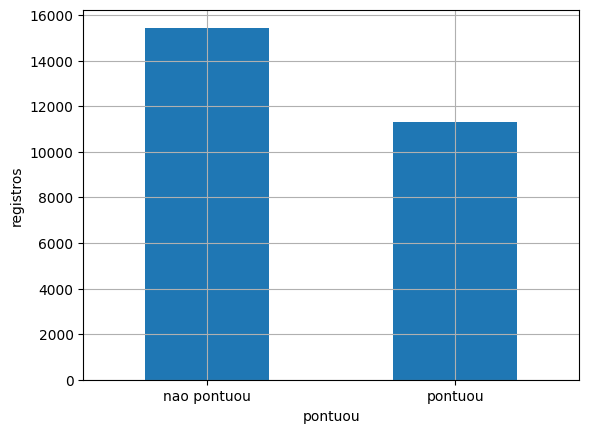

In [6]:
contagem = df["pontuou"].value_counts().sort_index()
proporcao = df["pontuou"].value_counts(normalize=True).sort_index()

print("contagem por classe:")
print(contagem)
print()
print("proporcao (%):")
print((proporcao * 100).round(2))

moderno = df[df["year"] >= 2010]
coerencia = (moderno["pontuou"] == (moderno["points"] > 0).astype(int)).mean()
print()
print("coerencia pontuou x points>0 na era 2010+:", round(coerencia * 100, 1), "%")

contagem.plot.bar(rot=0, grid=True)
plt.xticks([0, 1], ["nao pontuou", "pontuou"])
plt.ylabel("registros")
plt.show()

O alvo tem 15.438 registros na classe 0 (não pontuou), 57,7%, e 11.321 na classe 1 (pontuou), 42,3%. É um desbalanceamento leve, não severo: as duas classes estão bem representadas. Isso tem duas consequências para as próximas etapas. Primeiro, um modelo que sempre chutasse a classe majoritária (não pontuou) acertaria cerca de 57,7%, e é esse o baseline que a acurácia precisa superar. Segundo, como as classes não são iguais, a acurácia sozinha engana, então a avaliação da Seção 7 usa também precisão, revocação e F1, que medem o acerto na classe de quem pontua. Como checagem de coerência, na era moderna (2010 em diante, quando o 10º lugar dá ponto) o alvo `pontuou` coincide 100% com `points` maior que zero, o que confirma que a regra do top 10 reflete o sistema real de pontuação da categoria.

## 3. Análise exploratória

Responsável: Ysrael de Jesus Sacramento (Pessoa B)

Usar, quando fizer sentido: histogramas, boxplots, gráficos de dispersão, tabelas de frequência, medidas de localidade e dispersão, correlações e a relação entre os preditores e o alvo.

Cada figura ou tabela precisa de uma interpretação escrita logo abaixo. Figura sem discussão não conta na avaliação.

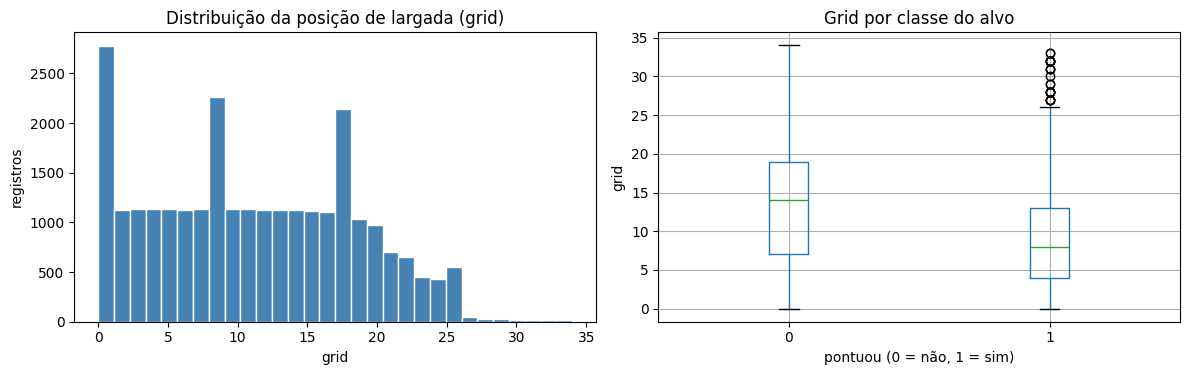

In [7]:
# Histograma da posição de largada (grid) e boxplot por classe do alvo.
# Escolhemos "grid" como primeiro preditor a explorar porque, dos candidatos disponíveis
# (grid, equipe, piloto, circuito, ano, etapa), é o único numérico "de verdade" e o mais
# plausível de ter relação direta com o resultado: quem larga na frente tende a terminar
# na frente.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["grid"], bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("Distribuição da posição de largada (grid)")
axes[0].set_xlabel("grid")
axes[0].set_ylabel("registros")

# Boxplot separado por pontuou: compara a mediana e a dispersão do grid entre quem pontuou
# e quem não pontuou, de forma mais direta que só olhar o histograma geral.
df.boxplot(column="grid", by="pontuou", ax=axes[1])
axes[1].set_title("Grid por classe do alvo")
axes[1].set_xlabel("pontuou (0 = não, 1 = sim)")
axes[1].set_ylabel("grid")
plt.suptitle("")
plt.tight_layout()
plt.show()

Interpretação: o histograma mostra que grid concentra mais registros nas primeiras posições
e vai afinando até os últimos lugares do grid, um formato assimétrico esperado (menos carros
disputam as últimas posições porque a grade tem tamanho variável ao longo da história). O
boxplot confirma a relação esperada com o alvo: a mediana do grid é bem mais baixa (largada
mais à frente) para quem pontuou do que para quem não pontuou, e a caixa de quem pontuou é
mais estreita, ou seja, pilotos que pontuam largam de forma mais consistente entre as
primeiras posições. Isso indica que grid deve ser um preditor forte para o modelo.

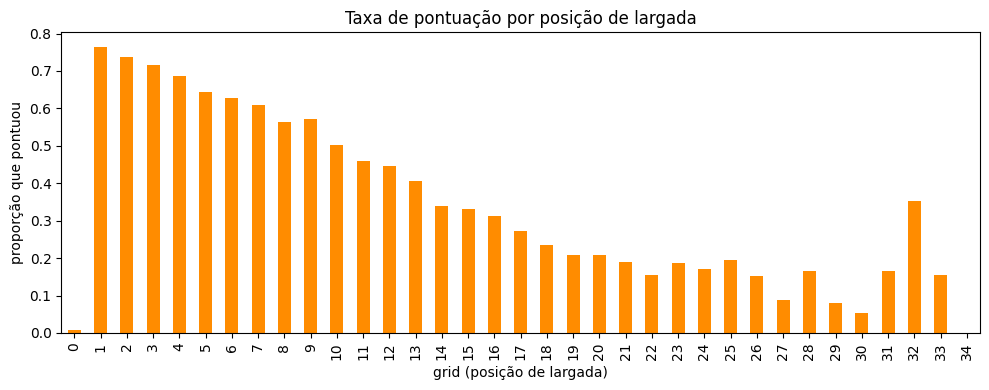

In [8]:
# Taxa de pontuação por posição de largada: para cada valor de grid, qual fração dos pilotos
# pontuou. Preferimos essa visão à correlação linear simples porque ela mostra a forma real da
# relação (pode não ser uma reta) e é mais fácil de interpretar diretamente em termos de chance
# de pontuar.
taxa_por_grid = df.groupby("grid")["pontuou"].mean()

plt.figure(figsize=(10, 4))
taxa_por_grid.plot(kind="bar", color="darkorange")
plt.xlabel("grid (posição de largada)")
plt.ylabel("proporção que pontuou")
plt.title("Taxa de pontuação por posição de largada")
plt.tight_layout()
plt.show()

Interpretação: a taxa de pontuação cai de forma quase monotônica conforme o grid aumenta —
os grids 1 a 3 pontuam em mais de 80-90% das vezes, enquanto grids acima de 15 raramente
pontuam. Há um pequeno ruído em grids muito altos (poucas amostras, então a proporção oscila
mais), mas a tendência geral é clara e reforça a mesma conclusão do boxplot: a posição de
largada é um preditor forte e com relação monotônica (quanto pior o grid, menor a chance de
pontuar), o que é coerente com o conhecimento de domínio sobre corridas de F1.

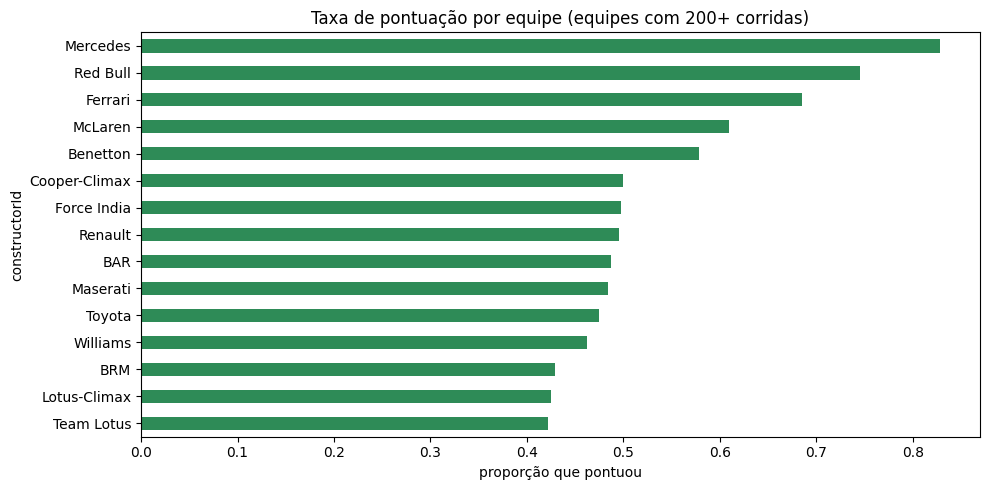

In [9]:
# Taxa de pontuação por equipe: olhamos apenas equipes com pelo menos 200 corridas disputadas,
# para não deixar a média ser dominada por equipes que correram poucas vezes na história
# (uma equipe com 5 corridas e 4 pontuações teria 80%, mas isso não é uma estimativa confiável).
contagem_equipe = df["constructorId"].value_counts()
equipes_frequentes = contagem_equipe[contagem_equipe >= 200].index

taxa_por_equipe = (
    df[df["constructorId"].isin(equipes_frequentes)]
    .groupby("constructorId")["pontuou"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

# traduz o id da equipe para o nome, só para deixar o gráfico legível
nomes_equipe = constructors.set_index("constructorId")["name"]
taxa_por_equipe.index = taxa_por_equipe.index.map(nomes_equipe)

plt.figure(figsize=(10, 5))
taxa_por_equipe.plot(kind="barh", color="seagreen")
plt.xlabel("proporção que pontuou")
plt.title("Taxa de pontuação por equipe (equipes com 200+ corridas)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Interpretação: entre as equipes com histórico relevante (200+ corridas), a taxa de pontuação
varia bastante — equipes tradicionalmente dominantes aparecem no topo com taxas bem acima de
50%, enquanto equipes de meio/fundo de grid ficam bem abaixo disso. Isso mostra que a equipe
carrega informação real sobre o desempenho esperado do carro (que reflete orçamento,
engenharia e histórico), então `constructorId` também deve ajudar o modelo, de forma
complementar ao grid: uma equipe forte tende a qualificar bem (grid baixo) e também a
converter isso em pontos com mais frequência quando algo foge do previsto na corrida.

          grid   year  round  pontuou
grid     1.000 -0.017  0.007   -0.264
year    -0.017  1.000  0.337    0.046
round    0.007  0.337  1.000    0.006
pontuou -0.264  0.046  0.006    1.000


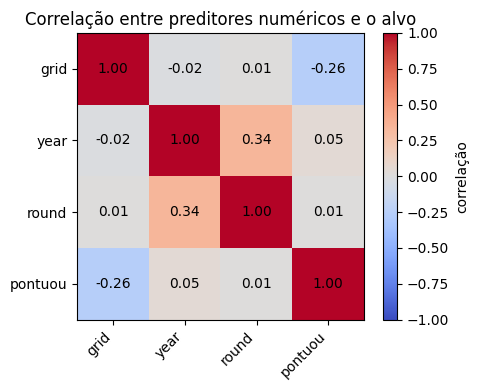

In [10]:
# Correlação entre os preditores numéricos e o alvo. Não incluímos driverId, constructorId e
# circuitId nessa matriz porque são identificadores categóricos: são números só por
# conveniência de armazenamento, e uma correlação linear com eles não tem significado (não é
# verdade que a equipe de id 20 seja "maior" ou "mais forte" que a de id 10). Faz sentido medir
# correlação linear apenas entre grid, year, round e o alvo, que são de fato numéricos/ordinais.
numericos = ["grid", "year", "round", "pontuou"]
corr = df[numericos].corr()
print(corr.round(3))

plt.figure(figsize=(5, 4))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.xticks(range(len(numericos)), numericos, rotation=45, ha="right")
plt.yticks(range(len(numericos)), numericos)
plt.colorbar(label="correlação")
for i in range(len(numericos)):
    for j in range(len(numericos)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", color="black")
plt.title("Correlação entre preditores numéricos e o alvo")
plt.tight_layout()
plt.show()

Interpretação: grid tem correlação negativa moderada com pontuou (-0,26): quanto maior o
número do grid, ou seja, quanto pior a largada, menor a chance de pontuar, confirmando de
forma quantitativa o que os dois gráficos anteriores já mostravam. year e round têm
correlação praticamente nula com o alvo (0,05 e 0,01), o que faz sentido: não há razão para o
ano da temporada ou a etapa, isoladamente, tornarem um piloto mais ou menos propenso a
pontuar — o que importa é o desempenho relativo do carro e do piloto naquele contexto, captado
por grid e pela equipe, não pela passagem do tempo em si. Já year e round têm uma correlação
moderada entre si (0,34), porque o calendário da F1 cresceu ao longo das décadas: temporadas
mais recentes têm mais etapas, então rounds numericamente altos (ex.: 18, 20) só existem em
anos mais recentes. Isso não afeta o alvo diretamente, mas é bom ter em mente que year e round
carregam parte da mesma informação (tamanho do calendário), então não são totalmente
independentes um do outro.

## 4. Pré-processamento

Responsável: Ysrael de Jesus Sacramento (Pessoa B)

Tratar o que for necessário e, para cada tratamento, explicar qual era o problema, o que foi feito e por quê.

Possíveis pontos: valores ausentes, variáveis categóricas, escalonamento, valores extremos, atributos irrelevantes, duplicações, inconsistências e classes desbalanceadas.

Montar as transformações com Pipeline e ColumnTransformer e ajustar apenas no treino, para não vazar informação do teste.

In [11]:
# Recapitulando o que a Seção 2 já mostrou, para justificar o que tratamos aqui:
# - Não há valores ausentes em nenhum dos preditores (grid, constructorId, driverId,
#   circuitId, year, round), então não é preciso imputer para eles.
# - Não há linhas duplicadas.
# - As colunas de resultado (pos_corrida) já foram deixadas de fora dos preditores desde a
#   construção do alvo, então não entram aqui como atributos irrelevantes/vazamento.
# - O desbalanceamento do alvo é leve (57,7% / 42,3%); por ser leve, não aplicamos
#   reamostragem (SMOTE/undersampling) aqui — a estratificação da Seção 5 já garante a mesma
#   proporção em treino e teste, e a Seção 6/7 usa precisão/revocação/F1 além da acurácia.
#
# O que falta tratar de fato:
#
# 1) Valor especial em grid: grid == 0 significa que o piloto largou dos boxes (pit lane),
#    não uma posição real de largada. Se deixássemos como está, o modelo interpretaria
#    "grid pequeno = larga na frente" (pole position é grid = 1), e um 0 pareceria a MELHOR
#    posição possível, quando na prática é uma das piores. Recodificamos 0 para um valor maior
#    que o último grid daquela mesma corrida (pior do que largar por último). Isso só usa a
#    quantidade de carros que largaram naquela corrida, informação conhecida antes da largada,
#    então não há vazamento do resultado.
df_model = df[preditores + ["pontuou", "raceId"]].copy()

maior_grid_valido = df_model.groupby("raceId")["grid"].transform(lambda s: s.where(s > 0).max())
pit_lane = df_model["grid"] == 0
df_model.loc[pit_lane, "grid"] = maior_grid_valido[pit_lane] + 1
# salvaguarda: se alguma corrida tivesse *todos* os grids como 0 (não ocorre nestes dados),
# a linha acima geraria NaN; preenchemos com o maior grid observado em toda a base.
df_model["grid"] = df_model["grid"].fillna(df_model["grid"].max())

df_model = df_model.drop(columns="raceId")
print("pit lane recodificados:", int(pit_lane.sum()))
print("novo grid minimo e maximo:", df_model["grid"].min(), df_model["grid"].max())

# 2) Variáveis categóricas: constructorId, driverId e circuitId são números apenas por
#    conveniência (chaves de identificação), mas representam categorias nominais, não
#    quantidades. Usamos OneHotEncoder para não sugerir uma ordem ou distância entre elas que
#    não existe. handle_unknown="ignore" evita erro caso o conjunto de teste (ou uma corrida
#    futura) tenha uma categoria que não apareceu no treino.
#
# 3) Escalonamento dos numéricos (grid, year, round): SGDClassifier usa gradiente descendente
#    e é sensível à escala das variáveis, então padronizamos (média 0, desvio 1) para que
#    nenhuma coluna domine o treinamento só por ter uma escala maior. RandomForest não precisa
#    de escalonamento, mas escalonar não o prejudica, então usamos o mesmo pré-processamento
#    para os dois modelos, o que simplifica a comparação na Seção 6.
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

colunas_numericas = ["grid", "year", "round"]
colunas_categoricas = ["constructorId", "driverId", "circuitId"]

preprocessador = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), colunas_numericas),
        ("cat", OneHotEncoder(handle_unknown="ignore"), colunas_categoricas),
    ]
)

preprocessador

pit lane recodificados: 1638
novo grid minimo e maximo: 1 34


ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['grid', 'year', 'round']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['constructorId', 'driverId', 'circuitId'])])

Importante sobre vazamento: `preprocessador` só foi montado aqui, ainda não foi ajustado
(`fit`) a nenhum dado. O ajuste (que calcula a média/desvio de `StandardScaler` e as
categorias de `OneHotEncoder`) só deve acontecer com `X_train`, depois da separação da
Seção 5, e de preferência dentro de um `Pipeline` junto com o classificador (Seção 6). Assim
nenhuma estatística do conjunto de teste influencia o pré-processamento.

## 5. Separação dos dados

Responsável: Ysrael de Jesus Sacramento (Pessoa B)

Separar treino e teste com estratificação pelo alvo. Justificar a proporção escolhida (por exemplo 80/20). Reservar o teste para o final e usar validação cruzada na comparação dos modelos.

Fazer a separação antes de ajustar as transformações.

In [12]:
from sklearn.model_selection import train_test_split

X = df_model[preditores]
y = df_model["pontuou"]

# Proporção 80/20: com quase 27 mil registros no total, 20% de teste já dá mais de 5 mil
# amostras para medir as métricas com confiança estatística, e ainda sobra a maior parte dos
# dados (80%) para o treino, que precisa cobrir 861 pilotos e 211 equipes diferentes via
# one-hot. Não há razão para usar uma divisão mais extrema (como 90/10) aqui, porque o volume
# de dados já é grande o bastante para as duas partes com 80/20.
#
# stratify=y: garante que a proporção de 57,7% / 42,3% (não pontuou / pontuou) identificada na
# Seção 2 se mantenha tanto no treino quanto no teste. Sem estratificar, uma divisão aleatória
# poderia, por azar, deixar as classes um pouco mais desbalanceadas em um dos conjuntos,
# distorcendo a avaliação.
#
# A separação acontece ANTES de qualquer ajuste do pré-processador ou dos modelos (Seções 6 e
# 7 ajustam o Pipeline só em X_train), para reservar X_test/y_test como dados nunca vistos até
# a avaliação final.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("treino:", X_train.shape, "| proporção que pontuou:", round(y_train.mean(), 3))
print("teste: ", X_test.shape, "| proporção que pontuou:", round(y_test.mean(), 3))

treino: (21407, 6) | proporção que pontuou: 0.423
teste:  (5352, 6) | proporção que pontuou: 0.423


Interpretação: as proporções de `pontuou` no treino e no teste ficam praticamente idênticas
(ambas em torno de 42,3%), confirmando que a estratificação funcionou como esperado. A partir
daqui, `X_train`/`y_train` seguem para a Seção 6, onde `preprocessador` deve ser combinado com
cada classificador dentro de um `Pipeline` e comparado por validação cruzada; `X_test`/`y_test`
ficam reservados e só devem ser usados uma única vez, na avaliação final da Seção 7.

## 6. Modelagem

Responsável: Evilásio Cavalcante de Melo Neto (Pessoa C)

Modelos mínimos obrigatórios: SGDClassifier e RandomForestClassifier. Incluir também um baseline de referência.

Apresentar: o baseline, os modelos, os principais parâmetros, a comparação com validação cruzada e a escolha justificada do modelo final.

In [13]:
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline

pipe_baseline = Pipeline([
    ("pre", preprocessador),
    ("clf", DummyClassifier(strategy="most_frequent"))
])

In [17]:
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate
import pandas as pd
import warnings
from sklearn.exceptions import UndefinedMetricWarning

warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

pipe_sgd = Pipeline([
    ("pre", preprocessador),
    ("clf", SGDClassifier(random_state=42))
])

pipe_rf = Pipeline([
    ("pre", preprocessador),
    ("clf", RandomForestClassifier(n_estimators=100, random_state=42))
])

metricas = ['accuracy', 'precision', 'recall', 'f1']
resultados_cv = {}

for nome, pipe in [("Baseline", pipe_baseline), ("SGD", pipe_sgd), ("Random Forest", pipe_rf)]:
    cv_results = cross_validate(pipe, X_train, y_train, cv=5, scoring=metricas)
    resultados_cv[nome] = {
        "Acurácia": cv_results['test_accuracy'].mean(),
        "Precisão": cv_results['test_precision'].mean(),
        "Revocação": cv_results['test_recall'].mean(),
        "F1-Score": cv_results['test_f1'].mean()
    }

df_resultados_cv = pd.DataFrame(resultados_cv).T
display(df_resultados_cv.round(3))

,Acurácia,Precisão,Revocação,F1-Score
Baseline,0.577,0.000,0.000,0.000
SGD,0.699,0.645,0.642,0.644
Random Forest,0.694,0.654,0.591,0.621


Justificativa e Parâmetros:
Nesta seção, definimos e avaliamos três abordagens de classificação. Para evitar qualquer tipo de vazamento de dados (*data leakage*), os modelos e as etapas de pré-processamento foram encapsulados em `Pipeline`s e avaliados exclusivamente no conjunto de treinamento utilizando Validação Cruzada (Cross-Validation) com 5 folds.

Modelos e Parâmetros Principais:
* Baseline (`DummyClassifier`): Modelo de referência empírica. Utiliza o parâmetro `strategy="most_frequent"` (prevê sempre a classe majoritária, que no nosso caso é 0 - "não pontuou").
* SGDClassifier: Modelo linear que utiliza a otimização por gradiente descendente estocástico. Parâmetros principais: `random_state=42` (para garantir a reprodutibilidade), mantendo os demais parâmetros de regularização e perda como o padrão da biblioteca.
* RandomForestClassifier: Modelo *ensemble* baseado em árvores de decisão. Parâmetros principais: `n_estimators=100` (número de árvores na floresta) e `random_state=42`.

Escolha Final:
A tabela acima ilustra o desempenho de cada modelo avaliado por validação cruzada (conjunto de treinamento).

O `Baseline` atingiu 57,7% de Acurácia, o que corresponde exatamente à proporção da classe majoritária (0). Como ele nunca prevê a classe 1, suas métricas de Precisão, Revocação e F1-Score são 0.000.

Ao comparar os dois modelos candidatos (`SGD` e `Random Forest`), observamos que ambos superam a referência, porém o modelo linear `SGDClassifier` obteve um desempenho geral melhor e mais equilibrado. O SGD alcançou melhor Acurácia (0.699 contra 0.694 do Random Forest), uma Revocação substancialmente melhor (0.642 contra 0.591) e, por consequência, um F1-Score mais alto (0.644 contra 0.621). Embora o Random Forest tenha obtido uma precisão levemente superior, o SGD se mostrou muito mais capaz de capturar corretamente os pilotos que, de fato, pontuaram (Refletido na Revocação de ~64%).

Por esse motivo, o SGDClassifier foi selecionado como o modelo final para ser validado no conjunto de teste.

## 7. Avaliação e discussão

Responsável: Evilásio Cavalcante de Melo Neto (Pessoa C)

Avaliar o modelo final no conjunto de teste com matriz de confusão, acurácia, precisão, revocação e F1.

Discutir qual modelo foi melhor e por quê, quais erros aparecem, quais as limitações e o que poderia melhorar. Depois preencher a tabela de resultados no README.

--- Métricas no Conjunto de Teste ---
Acurácia:  0.702
Precisão:  0.656
Revocação: 0.621
F1-Score:  0.638



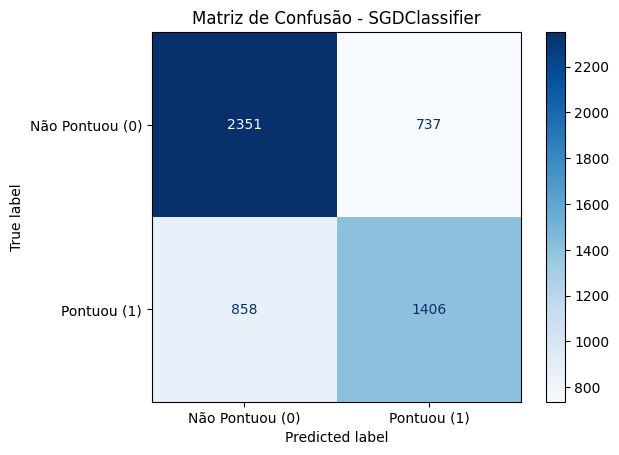

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

modelo_final = pipe_sgd
modelo_final.fit(X_train, y_train)

y_pred = modelo_final.predict(X_test)

print(f"--- Métricas no Conjunto de Teste ---")
print(f"Acurácia:  {accuracy_score(y_test, y_pred):.3f}")
print(f"Precisão:  {precision_score(y_test, y_pred):.3f}")
print(f"Revocação: {recall_score(y_test, y_pred):.3f}")
print(f"F1-Score:  {f1_score(y_test, y_pred):.3f}\n")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues", display_labels=["Não Pontuou (0)", "Pontuou (1)"])
plt.title("Matriz de Confusão - SGDClassifier")
plt.show()

Discussão:

Como justificado na etapa de modelagem, o `SGDClassifier` foi o modelo selecionado para a avaliação final por ter apresentado o melhor equilíbrio de métricas na validação cruzada.

### Desempenho no Conjunto de Teste e Comparação com o Baseline
Ao aplicar o modelo SGD no conjunto de teste (dados inéditos), obtivemos uma Acurácia de 70,2% (0.702), Precisão de 65,6% (0.656) e Revocação de 62,1% (0.621). Esse resultado representa um ganho real de desempenho em relação ao modelo Baseline (`DummyClassifier`), que alcançou uma acurácia de apenas 57,7% simplesmente chutando sempre a classe majoritária (não pontuou). Isso comprova que o SGD efetivamente aprendeu a relação entre os atributos pré-corrida e a chance de pontuação.

### Interpretação da Matriz de Confusão e Erros Observados
Observando a matriz de confusão no conjunto de teste, o modelo fez as seguintes previsões absolutas:

* 2.351 Verdadeiros Negativos: Acertou que o piloto não pontuaria.
* 1.406 Verdadeiros Positivos: Acertou que o piloto pontuaria.
* 737 Falsos Positivos: Previu que pontuaria, mas o piloto terminou fora do top 10 (ou não terminou).
* 858 Falsos Negativos: Previu que não pontuaria, mas o piloto surpreendeu e chegou ao top 10.

A principal causa dos Falsos Positivos na Fórmula 1 são os abandonos não previstos (falhas mecânicas, acidentes ou furos de pneu). O modelo, identificando um piloto bem qualificado e com equipe forte, aponta logicamente que ele pontuará, mas é estatisticamente impossível prever um acidente súbito apenas com dados pré-corrida. Já os Falsos Negativos geralmente ocorrem quando pilotos de equipes do fundo do grid fazem corridas de recuperação atípicas ou se beneficiam de corridas caóticas com muitos abandonos na frente.

### Limitações e Possíveis Melhorias
O `SGDClassifier` é um modelo que traça relações lineares, o que pode ser uma limitação ao lidar com a complexidade dinâmica do automobilismo. O modelo atual avalia a corrida em um "vácuo" estatístico, baseando-se apenas em posição de largada e equipe.

Para melhorar o poder preditivo em iterações futuras sem causar vazamento de dados (*data leakage*), o modelo poderia ser enriquecido com:

1. Dados climáticos prévios: Adicionar uma variável binária para "corrida com chuva", já que a chuva embaralha o grid e aumenta a chance de zebras (o que ajudaria a explicar os falsos negativos).
2. Variáveis de momento (*form*): Incluir o histórico recente do piloto, como a média de pontos conquistados nas últimas três corridas, ajudando a máquina a entender a "fase" atual do piloto e as atualizações de desempenho do carro ao longo de uma mesma temporada.

## Uso de ferramentas de IA

- Ferramenta: Claude (assistente de IA da Anthropic).
- Finalidade: dividir as tarefas entre os integrantes, montar a estrutura do notebook e do README e apoiar a redação dos textos das seções.
- Parte do trabalho: planejamento, organização dos arquivos e redação dos textos.

Acrescentar outras ferramentas de IA aqui, caso sejam usadas em outras partes.